# 下一课：CartPole + Double DQN

上一课我们已经用标准 `DQN` 解决了 `CartPole-v1`。

这一课我们继续往前走，学习 `Double DQN`。

它的核心目标很明确：

**减少标准 DQN 对 Q 值的高估问题。**

这一课你会学到：
- 为什么标准 DQN 容易高估 Q 值
- Double DQN 和 DQN 只差哪一步
- 在 `CartPole` 上怎么把标准 DQN 改成 Double DQN


## 1. 标准 DQN 的一个经典问题

标准 DQN 在计算 target 时通常这样写：

$target = r + \gamma \max_{a'} Q_{target}(s', a')$

问题在于：

- 同一个网络既负责“选最大值”
- 又负责“给这个最大值打分”

如果某个动作只是因为噪声被估高了，`max` 操作就会偏爱它。
久而久之，Q 值就可能整体偏高。

这就叫做 `overestimation`，也就是高估问题。


## 2. Double DQN 的核心想法

Double DQN 的改法其实非常巧妙：

- 用主网络 `q_net` 来选动作
- 用目标网络 `target_net` 来给这个动作打分

也就是把“选动作”和“估价值”拆开。

标准 DQN：

$target = r + \gamma \max_{a'} Q_{target}(s', a')$

Double DQN：

$target = r + \gamma Q_{target}(s', \arg\max_{a'} Q_{online}(s', a'))$

你会发现差别很小，但思想很重要：

**主网络负责做决定，目标网络负责更稳地评估这个决定。**


In [1]:
import random
import warnings
from collections import deque

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [2]:
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.zeros(1, device='cuda')
            return torch.device('cuda')
        except Exception as e:
            warnings.warn(f'检测到 CUDA，但当前环境无法真正使用 GPU，已回退到 CPU。原因: {e}')
    return torch.device('cpu')


device = pick_device()
print('当前设备:', device)
if torch.cuda.is_available():
    print('检测到 CUDA 设备:', torch.cuda.get_device_name(0))


当前设备: cuda
检测到 CUDA 设备: NVIDIA GeForce RTX 5090


In [3]:
env = gym.make('CartPole-v1')
state, info = env.reset(seed=42)
print('初始状态:', state)
print('状态维度:', env.observation_space.shape[0])
print('动作数量:', env.action_space.n)


初始状态: [ 0.027 -0.006  0.036  0.02 ]
状态维度: 4
动作数量: 2


In [4]:
class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return np.array(states), actions, rewards, np.array(next_states), dones

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        return self.net(x)


def to_tensor(x, device):
    return torch.tensor(x, dtype=torch.float32, device=device)


## 3. 训练 Double DQN

这段代码和上一课的标准 DQN 非常像。

真正最关键的差别只在构造 target 的几行：

- 先用 `q_net` 找出下一状态里最优动作
- 再用 `target_net` 读取这个动作对应的 Q 值

这一小步，就是 Double DQN 的灵魂。


In [5]:
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(state_dim, action_dim, hidden_dim=128).to(device)
target_net = QNetwork(state_dim, action_dim, hidden_dim=128).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=5e-4)
criterion = nn.SmoothL1Loss()
replay_buffer = ReplayBuffer(capacity=50000)

gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.997
epsilon_min = 0.02
episodes = 300
max_steps = 500
batch_size = 128
target_update_freq = 20
train_start = 1000

episode_rewards = []
loss_history = []
buffer_sizes = []

for episode in range(episodes):
    state, info = env.reset()
    total_reward = 0.0

    for step in range(max_steps):
        state_tensor = to_tensor(state, device).unsqueeze(0)

        with torch.no_grad():
            q_values = q_net(state_tensor)

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(torch.argmax(q_values, dim=1).item())

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        buffer_sizes.append(len(replay_buffer))

        state = next_state
        total_reward += reward

        if len(replay_buffer) >= train_start:
            states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

            states_tensor = to_tensor(states, device)
            next_states_tensor = to_tensor(next_states, device)
            actions_tensor = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
            rewards_tensor = torch.tensor(rewards, dtype=torch.float32, device=device)
            dones_tensor = torch.tensor(dones, dtype=torch.float32, device=device)

            current_q_values = q_net(states_tensor)
            chosen_q_values = current_q_values.gather(1, actions_tensor).squeeze(1)

            with torch.no_grad():
                # Double DQN 的关键：
                # 先用主网络 q_net 选择下一状态的最优动作
                next_actions = q_net(next_states_tensor).argmax(dim=1, keepdim=True)

                # 再用目标网络 target_net 给这个动作打分
                next_q_values_target = target_net(next_states_tensor)
                selected_next_q_values = next_q_values_target.gather(1, next_actions).squeeze(1)

                targets = rewards_tensor + gamma * selected_next_q_values * (1 - dones_tensor)

            loss = criterion(chosen_q_values, targets)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(q_net.parameters(), max_norm=10.0)
            optimizer.step()

            loss_history.append(float(loss.item()))

        if done:
            break

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if (episode + 1) % target_update_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

print('训练完成。')
print('最后 20 轮平均 reward:', round(float(np.mean(episode_rewards[-20:])), 2))


训练完成。
最后 20 轮平均 reward: 60.35


## 4. 看 reward 曲线

和上一课一样，这里最重要的观察指标仍然是每轮总 reward。

如果训练正常，整体趋势应该是逐渐上升的。
Double DQN 的价值通常不是“每次都爆高”，而是训练更稳、对 Q 值的估计更靠谱。


C:\Users\80740\AppData\Local\Temp\ipykernel_32128\3899257459.py:23: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_32128\3899257459.py:23: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_32128\3899257459.py:23: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_32128\3899257459.py:23: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_32128\3899257459.py:23: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_32128\3899257459.py:23: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931})

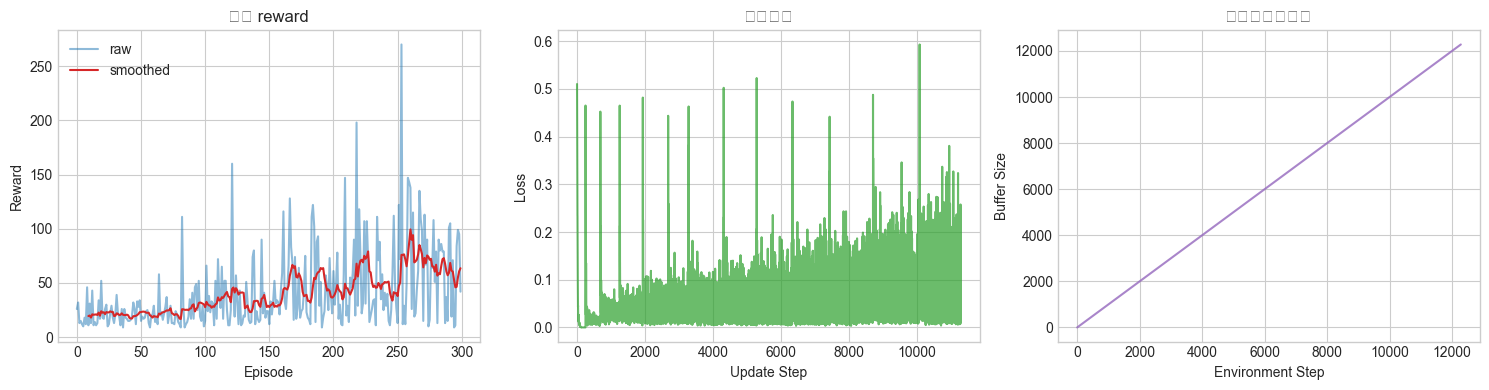

In [6]:
window = 10
smoothed_rewards = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(episode_rewards, color='#1f77b4', alpha=0.5, label='raw')
axes[0].plot(range(window - 1, len(episode_rewards)), smoothed_rewards, color='#d62728', label='smoothed')
axes[0].set_title('每轮 reward')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].legend()

axes[1].plot(loss_history, color='#2ca02c', alpha=0.7)
axes[1].set_title('训练损失')
axes[1].set_xlabel('Update Step')
axes[1].set_ylabel('Loss')

axes[2].plot(buffer_sizes, color='#9467bd', alpha=0.8)
axes[2].set_title('经验池大小变化')
axes[2].set_xlabel('Environment Step')
axes[2].set_ylabel('Buffer Size')

plt.tight_layout()
plt.show()


## 5. 多测几次看平均表现

和上一课一样，我们不只测 1 次，而是测 5 次求平均。
这样更能看出模型的稳定表现，而不是被某一次随机结果误导。


In [7]:
test_env = gym.make('CartPole-v1')
test_rewards = []

q_net.eval()
with torch.no_grad():
    for episode_idx in range(5):
        state, info = test_env.reset(seed=123 + episode_idx)
        test_reward = 0.0
        for step in range(500):
            state_tensor = to_tensor(state, device).unsqueeze(0)
            action = int(torch.argmax(q_net(state_tensor), dim=1).item())
            state, reward, terminated, truncated, info = test_env.step(action)
            test_reward += reward
            if terminated or truncated:
                break
        test_rewards.append(test_reward)

print('测试 rewards:', test_rewards)
print('测试平均 reward:', round(float(np.mean(test_rewards)), 2))
test_env.close()


测试 rewards: [126.0, 103.0, 114.0, 121.0, 124.0]
测试平均 reward: 117.6


## 6. 这节课最值得记住的那一行

如果这节课你只想记住一件事，那就是这两步：

1. `next_actions = q_net(next_states_tensor).argmax(...)`
   主网络负责选动作。

2. `selected_next_q_values = target_net(...).gather(..., next_actions)`
   目标网络负责给这个动作估值。

这就是 Double DQN 相比标准 DQN 的本质区别。


## 7. 下一课最自然学什么

学完 Double DQN 后，最自然的下一步一般是：
- `Dueling DQN`
- `Prioritized Replay`
- 把这些技巧组合成更完整的 DQN 变体

如果按顺序学，我最推荐你下一课先看 `Dueling DQN`。
